In [51]:
import json
from pathlib import Path

# must import pysr before torch because julia kernel init weirdness
from pysr import PySRRegressor
# torch AFTER pysr, dont let ruff/isort/whatever reorder this
import torch
import numpy as np

import matplotlib.pyplot as plt
from jaxtyping import Int, Float
from tqdm import tqdm
from scipy.fft import fft2
from scipy.optimize import curve_fit

In [52]:
# load activations for each prompt
def load_activations(
		model_name: str,
		base_path: Path = Path("../docs/demo"),
	) -> tuple[
		list[dict],
		list[np.lib.npyio.NpzFile],
	]:
	model_path: Path = base_path / model_name
	with open(model_path / "prompts.jsonl") as f:
		prompts = [json.loads(line) for line in f]
	
	activations = [
		np.load(model_path / "prompts" / p['hash'] / "activations.npz")
		for p in prompts
	]

	return prompts, activations

PROMPTS, ACTIVATIONS = load_activations("pythia-14m")


In [53]:
ACTIVATIONS[0]

NpzFile '..\\docs\\demo\\pythia-14m\\prompts\\0FXa04qYJZZbhploNh7DVA\\activations.npz' with keys: blocks.0.attn.hook_pattern, blocks.1.attn.hook_pattern, blocks.2.attn.hook_pattern, blocks.3.attn.hook_pattern, blocks.4.attn.hook_pattern...

In [54]:
for i in range(5):
	print(PROMPTS[i]['text'])
	print("="*50)

rent types of very small pasta – barely something to start when talking about the evolution of Pasta.

Pastas used in the game. Unfortunately, the macs where never used

Which is one of the saddest things about the project, really. It had the framework and
he problem I realized when doing some tests is that people never look at the bill! They think it’s some kind of prop, so they never actually read its details.

Plus, if you’re zoomed out too much, you can’t actually read it, so it’s hard to know what’s goi
ns through several seemingly random mutations over time, with the most apt permutation surviving. This genetic car simulator is, in my opinion, a great example of actual evolution of a species facing a challenge. But is it a game?

In a game, you need to c
Topic: reinvent midnight madness

Amazon announced a new service at the AWS re:Invent Midnight Madness event. Amazon Sumerian is a solution that aims to make it easier for developers to build virtual reality, augmented reality, a

In [55]:
ACTIVATIONS[1]["blocks.4.attn.hook_pattern"][0,0].shape

(70, 70)

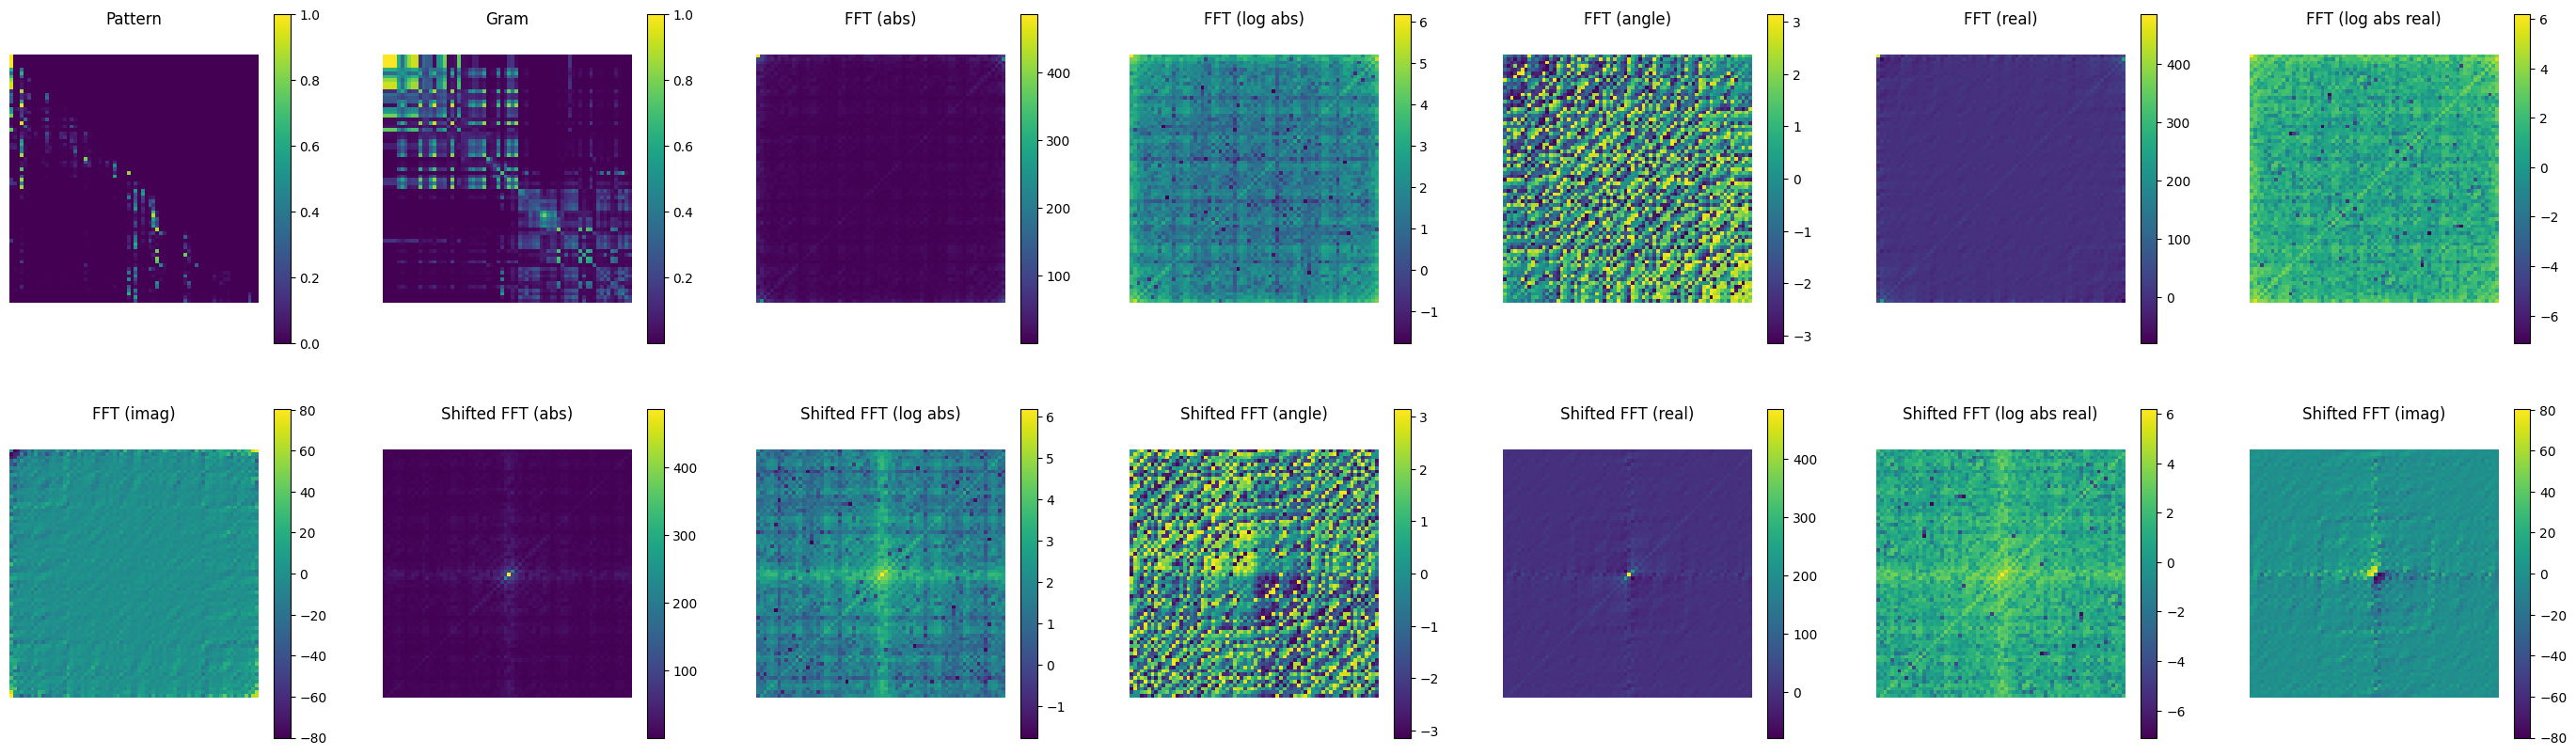

(<Figure size 3500x1000 with 28 Axes>,
 array([[<Axes: title={'center': 'Pattern'}>,
         <Axes: title={'center': 'Gram'}>,
         <Axes: title={'center': 'FFT (abs)'}>,
         <Axes: title={'center': 'FFT (log abs)'}>,
         <Axes: title={'center': 'FFT (angle)'}>,
         <Axes: title={'center': 'FFT (real)'}>,
         <Axes: title={'center': 'FFT (log abs real)'}>],
        [<Axes: title={'center': 'FFT (imag)'}>,
         <Axes: title={'center': 'Shifted FFT (abs)'}>,
         <Axes: title={'center': 'Shifted FFT (log abs)'}>,
         <Axes: title={'center': 'Shifted FFT (angle)'}>,
         <Axes: title={'center': 'Shifted FFT (real)'}>,
         <Axes: title={'center': 'Shifted FFT (log abs real)'}>,
         <Axes: title={'center': 'Shifted FFT (imag)'}>]], dtype=object))

In [56]:

def plot_pattern_info(
		pattern: Float[np.ndarray, "n_ctx n_ctx"],
        show: bool = True,
    ) -> tuple[plt.Figure, plt.Axes]:

    gram = pattern @ pattern.T
    fft = fft2(gram)
    fft_shifted = np.fft.fftshift(fft)
    data: dict = {
        "Pattern": pattern,
        "Gram": gram,
        "FFT (abs)": np.abs(fft),
        "FFT (log abs)": np.log(np.abs(fft)),
        "FFT (angle)": np.angle(fft),
        "FFT (real)": np.real(fft),
        "FFT (log abs real)": np.log(np.abs(np.real(fft))),
        "FFT (imag)": np.imag(fft),
        "Shifted FFT (abs)": np.abs(fft_shifted),
        "Shifted FFT (log abs)": np.log(np.abs(fft_shifted)),
        "Shifted FFT (angle)": np.angle(fft_shifted),
        "Shifted FFT (real)": np.real(fft_shifted),
        "Shifted FFT (log abs real)": np.log(np.abs(np.real(fft_shifted))),
        "Shifted FFT (imag)": np.imag(fft_shifted),
    }

    # Create subplots and add colorbars using a loop
    n_data: int = len(data)
    n_cols: int = round(n_data / 2)
    fig, axs = plt.subplots(2, n_cols, figsize=(5 * n_cols, 10))
    for ax, (title, datum) in zip(axs.flat[:n_data], data.items()):
        cax = ax.matshow(datum)
        fig.colorbar(cax, ax=ax)
        ax.set_title(title)
        ax.axis("off")

    if show:
        plt.show()
    
    return fig, axs


def get_single_attn_pattern(
    sample: int,
    layer: int,
    head: int,
    activations = ACTIVATIONS,
) -> Float[np.ndarray, "n_ctx n_ctx"]:
    return activations[sample][f"blocks.{layer}.attn.hook_pattern"][0, head]

plot_pattern_info(get_single_attn_pattern(1, 4, 0))

In [58]:
def plot_comparison(
    original_data: np.ndarray,
    fitted_model: np.ndarray,
    freqs: np.ndarray,
    title: str = "FFT Data vs. Fitted Model and Difference"
) -> None:
    """Plot original data, fitted model, and their difference side by side."""
    difference = original_data - fitted_model
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title)
    
    # Find common vmin/vmax for original and fitted data
    vmin = min(original_data.min(), fitted_model.min())
    vmax = max(original_data.max(), fitted_model.max())
    
    # Original FFT Data
    im0 = axes[0].imshow(
        original_data, 
        extent=(freqs.min(), freqs.max(), freqs.min(), freqs.max()),
        origin='lower',
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_title('Original FFT Data')
    axes[0].set_xlabel('Frequency fx')
    axes[0].set_ylabel('Frequency fy')
    fig.colorbar(im0, ax=axes[0], orientation='vertical')
    
    # Fitted Model
    im1 = axes[1].imshow(
        fitted_model, 
        extent=(freqs.min(), freqs.max(), freqs.min(), freqs.max()),
        origin='lower',
        vmin=vmin,
        vmax=vmax
    )
    axes[1].set_title('Fitted Gaussian Model')
    axes[1].set_xlabel('Frequency fx')
    axes[1].set_ylabel('Frequency fy')
    fig.colorbar(im1, ax=axes[1], orientation='vertical')
    
    # Difference plot with symmetric red-blue colormap
    diff_vmax = max(abs(difference.min()), abs(difference.max()))
    im2 = axes[2].imshow(
        difference, 
        extent=(freqs.min(), freqs.max(), freqs.min(), freqs.max()),
        origin='lower',
        cmap='RdBu_r',  # Red-Blue diverging colormap
        vmin=-diff_vmax,     # Symmetric limits around zero
        vmax=diff_vmax
    )
    axes[2].set_title('Difference (Original - Fitted)')
    axes[2].set_xlabel('Frequency fx')
    axes[2].set_ylabel('Frequency fy')
    fig.colorbar(im2, ax=axes[2], orientation='vertical')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [59]:


# set up matrix
pattern = get_single_attn_pattern(1, 4, 0)
gram = pattern @ pattern.T
fft = np.fft.fft2(gram)
fft_shifted = np.fft.fftshift(fft)
log_fft = np.log(np.abs(fft_shifted) + 1e-8)  # Add epsilon to prevent log(0)
matrix = log_fft

# set up pysr
model = PySRRegressor(
    maxsize=20,
    niterations=40,  # < Increase me for better results
    binary_operators=["+", "*", "^"],
    unary_operators=[
        "cos",
        "exp",
        "sin",
        "inv(x) = 1/x",
        # ^ Custom operator (julia syntax)
    ],
    extra_sympy_mappings={"inv": lambda x: 1 / x},
    # ^ Define operator for SymPy as well
    elementwise_loss="loss(prediction, target) = (prediction - target)^2",
    # ^ Custom loss function (julia syntax)
)
# This will set up the model for 40 iterations of the search code, which contains hundreds of thousands of mutations and equation evaluations.

# Let's train this model on our dataset:
X = np.indices(matrix.shape).reshape(2, -1).T
y = matrix.ravel()
model.fit(X, y)
	

f:\projects\attention-motifs\.venv\Lib\site-packages\pysr\sr.py:2766: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
f:\projects\attention-motifs\.venv\Lib\site-packages\pysr\sr.py:84: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 9.070e+03
Progress: 63 / 1240 total iterations (5.081%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.684e-01  1.594e+01  y = 1.6963
5           7.673e-01  3.698e-04  y = (x₁ + x₀) ^ 0.12641
7           7.648e-01  1.600e-03  y = ((x₁ + x₀) ^ 0.074964) * 1.237
8           7.634e-01  1.815e-03  y = inv(cos(cos(-0.8522 ^ x₀))) ^ 0.93349
9           7.456e-01  2.359e-02  y = exp(0.41518 ^ sin(cos(cos(x₁ * 0.082863))))
10          7.407e-01  6.607e-03  y = inv(cos(1.029 ^ cos(x₀ ^ 0.52382))) + -0.16738
11          7.276e-01  1.792e-02  y = 1.7751 ^ ((cos(cos(x₀ * -2.7396)) * 1.2931) + -0.08223...
                                      1)
12          7.262e-01  1.917e-03  y = inv(cos(cos(1.1337 ^ (x₀ * 0.25309)) * 0.86867)) + 0.4...
                 

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          1.6962938   
	1         0.001462                      1.5268325 ^ (x1 ^ 0.06908681)   
	2   >>>>  0.071339                  2.0858388 ^ sin(x1 * 0.043473836)   
	3         0.023616             2.0394108 ^ cos(cos(x1 * 0.047167763))   
	4         0.009978   cos(sin(exp(sin(x0 * 0.044978335)))) * 2.4309378   
	5         0.005228  2.215235 ^ cos(sin(cos(x1 * 0.045328658) * 1.7...   
	6         0.000044  2.215235 ^ cos(sin(1.7686554 * cos((-0.0882982...   
	7         0.004609  exp((sin((x1 + (x1 * -0.8747284)) + -2.7948346...   
	8         0.006429  exp(exp((sin((x1 + (x1 * -0.8743123)) + -2.815...   
	9         0.003681  exp(exp(sin((sin(x1 + ((x1 * -0.87189996) + -2...   
	10        0.001643  exp(exp((exp(sin((x1 * -0.87405163) + (x1 + -2...   
	
	        loss  complexity  
	0   0.768402           1  
	1   0.763923           5  
	2   0.711324           6  
	3   0.694722           7  
	4   0.680996           9  
	5   0.677445          10  
	6   0.677386          12  
	7   0.674271          13  
	8   0.669950          14  
	9   0.667488          15  
	10  0.665299          17  
]

In [60]:
model.equations_

,complexity,loss,equation,score,sympy_format,lambda_format
0,1,0.768402,1.6962938,0.000000,1.69629380000000,PySRFunction(X=>1.69629380000000)
1,5,0.763923,1.5268325 ^ (x1 ^ 0.06908681),0.001462,1.5268325**(x1**0.06908681),PySRFunction(X=>1.5268325**(x1**0.06908681))
2,6,0.711324,2.0858388 ^ sin(x1 * 0.043473836),0.071339,2.0858388**sin(x1*0.043473836),PySRFunction(X=>2.0858388**sin(x1*0.043473836))
3,7,0.694722,2.0394108 ^ cos(cos(x1 * 0.047167763)),0.023616,2.0394108**cos(cos(x1*0.047167763)),PySRFunction(X=>2.0394108**cos(cos(x1*0.047167...
4,9,0.680996,cos(sin(exp(sin(x0 * 0.044978335)))) * 2.4309378,0.009978,cos(sin(exp(sin(x0*0.044978335))))*2.4309378,PySRFunction(X=>cos(sin(exp(sin(x0*0.044978335...
5,10,0.677445,2.215235 ^ cos(sin(cos(x1 * 0.045328658) * 1.7...,0.005228,2.215235**cos(sin(cos(x1*0.045328658)*1.7686554)),PySRFunction(X=>2.215235**cos(sin(cos(x1*0.045...
6,12,0.677386,2.215235 ^ cos(sin(1.7686554 * cos((-0.0882982...,0.000044,2.215235**cos(sin(1.7686554*cos((x0 - 0.088298...,PySRFunction(X=>2.215235**cos(sin(1.7686554*co...
7,13,0.674271,exp((sin((x1 + (x1 * -0.8747284)) + -2.7948346...,0.004609,exp(sin(x1*(-0.8747284) + x1 - 2.7948346)*0.25...,PySRFunction(X=>exp(sin(x1*(-0.8747284) + x1 -...
8,14,0.669950,exp(exp((sin((x1 + (x1 * -0.8743123)) + -2.815...,0.006429,exp(exp(sin(x1*(-0.8743123) + x1 - 2.8159454)*...,PySRFunction(X=>exp(exp(sin(x1*(-0.8743123) + ...
9,15,0.667488,exp(exp(sin((sin(x1 + ((x1 * -0.87189996) + -2...,0.003681,exp(exp(sin(sin(x1*(-0.87189996) + x1 - 2.9051...,PySRFunction(X=>exp(exp(sin(sin(x1*(-0.8718999...


In [61]:
idxs = np.indices(matrix.shape).reshape(2, -1).T
idxs.shape

(4900, 2)

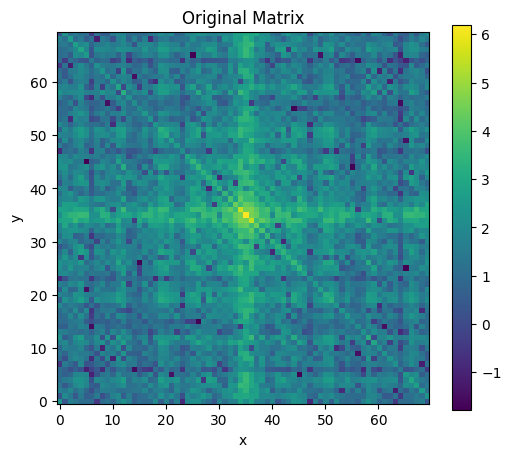

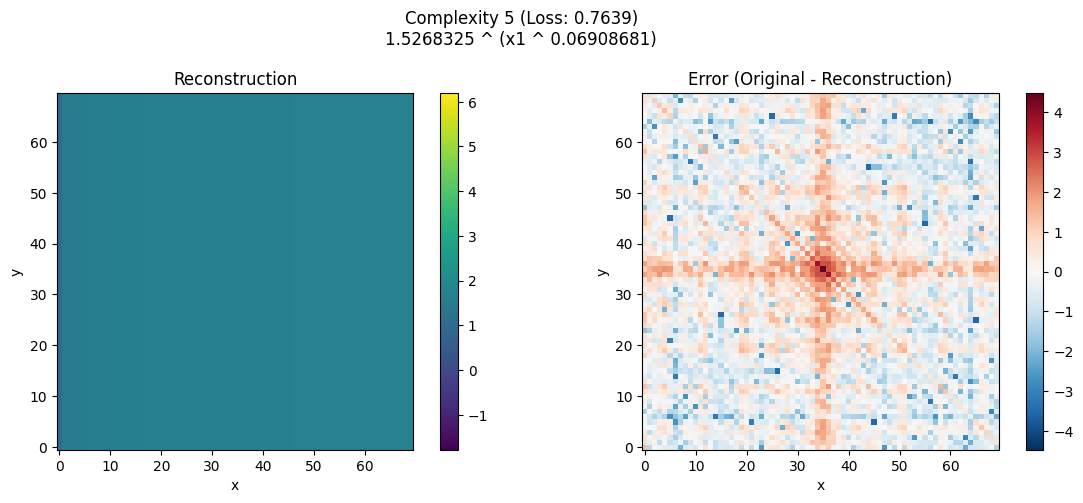

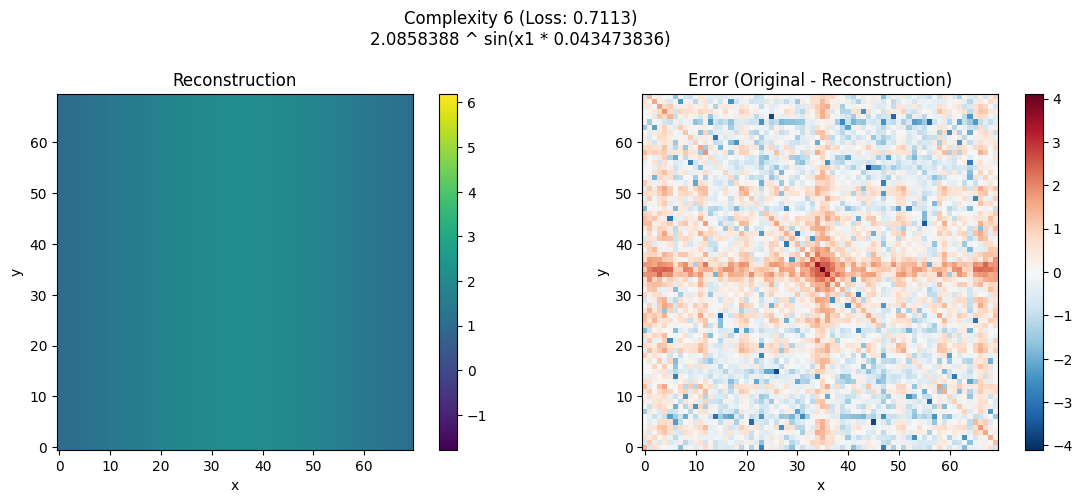

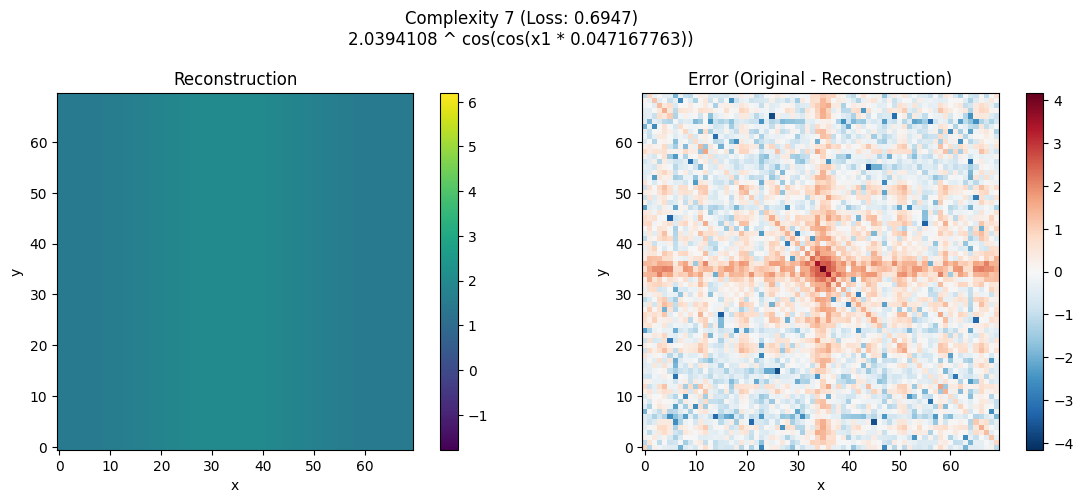

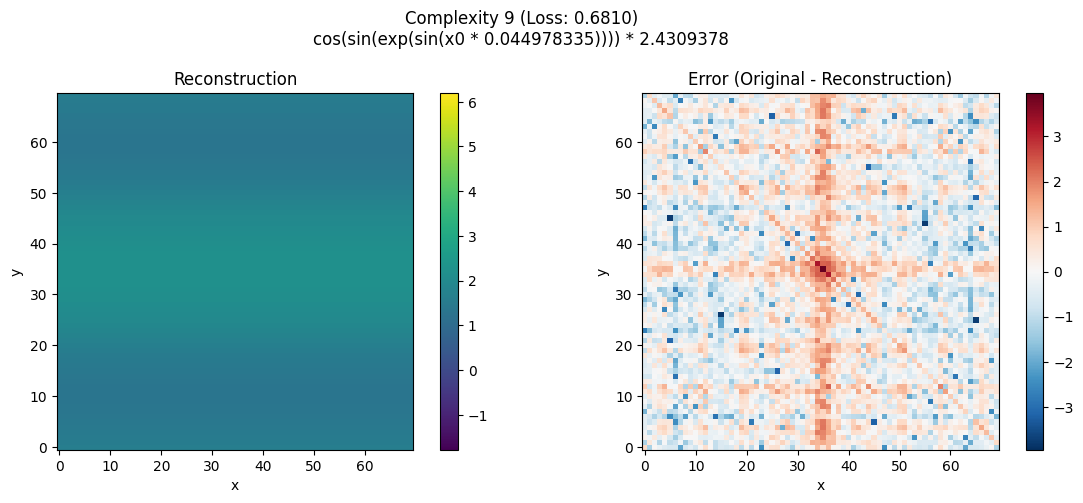

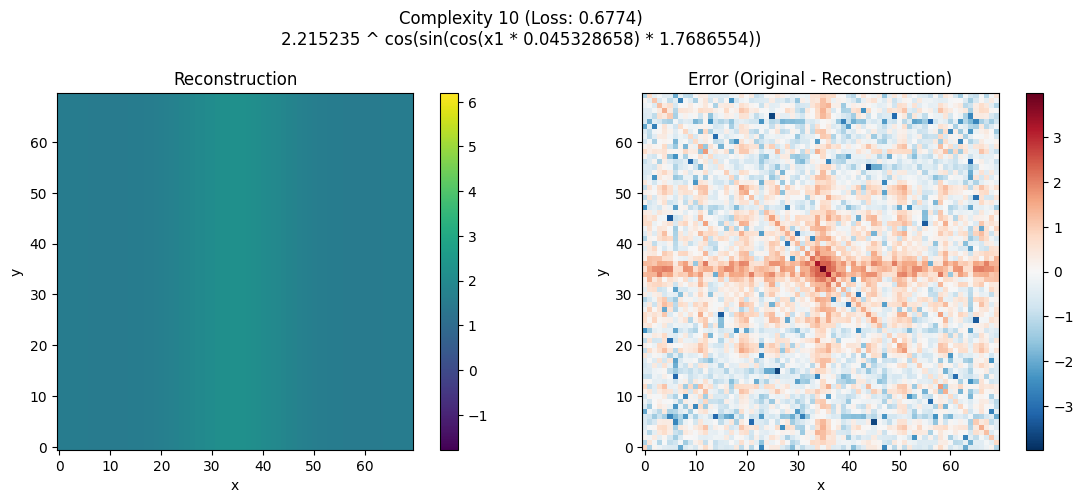

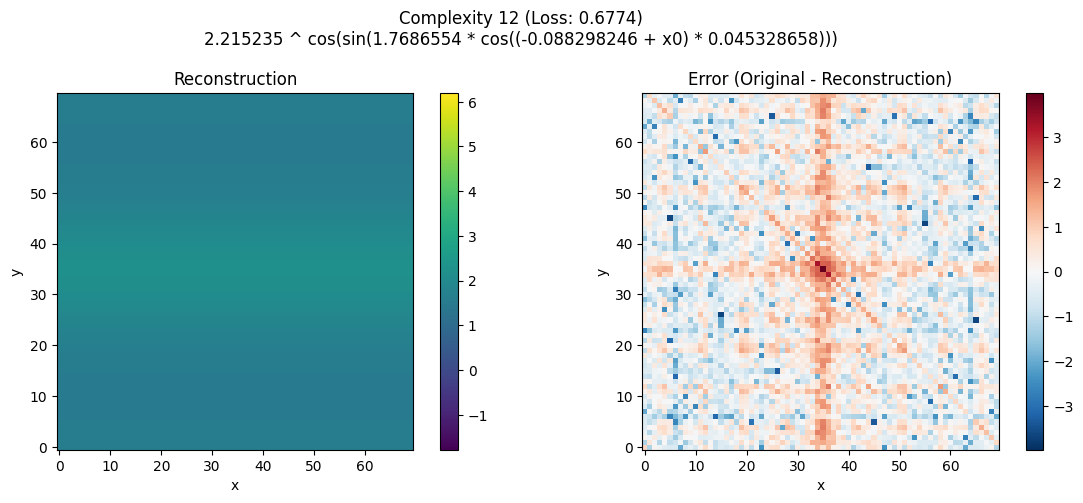

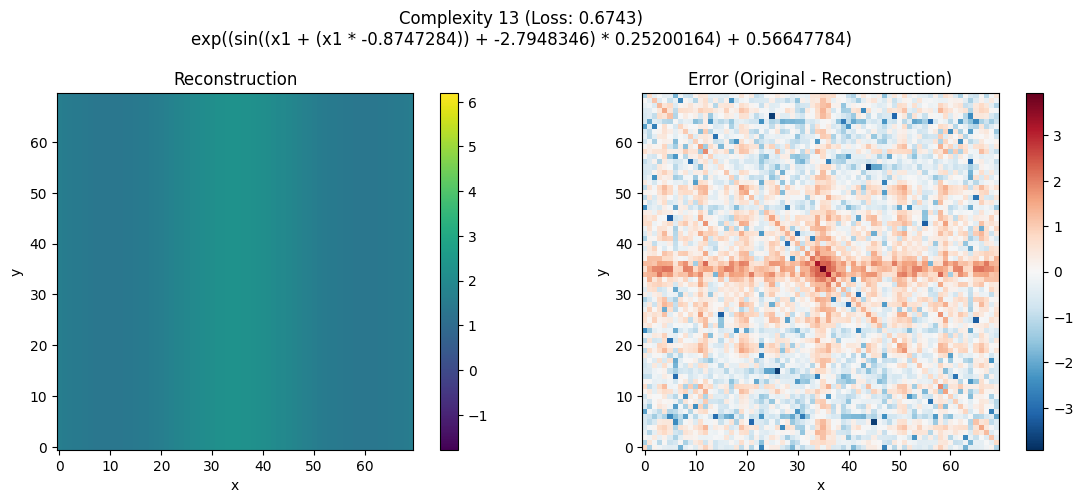

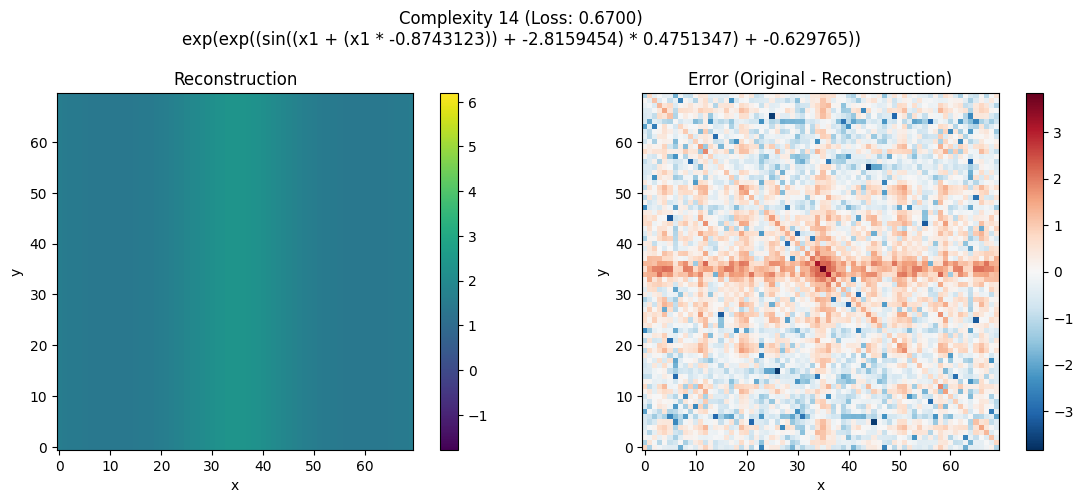

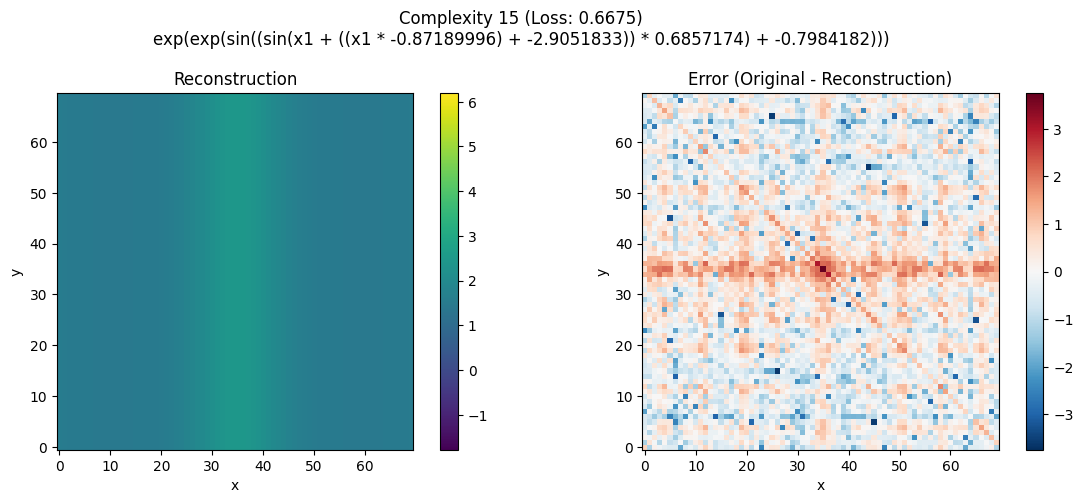

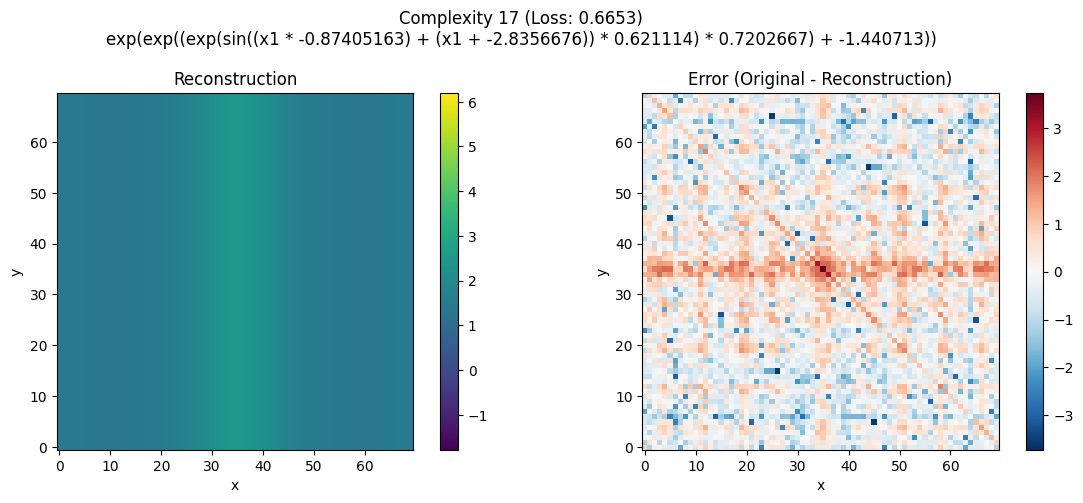

In [63]:
def plot_reconstructions(
    original_matrix: np.ndarray,
    model_equations,
    start_complexity: int = 2
) -> None:
    """
    Plot original matrix and reconstructions at each complexity level.
    
    Args:
        original_matrix: The original matrix being approximated
        model_equations: DataFrame containing the PySR equations
        start_complexity: Minimum complexity to start showing (default 2)
    """
    # Generate frequency coordinates
    N = original_matrix.shape[0]
    freqs = np.fft.fftshift(np.fft.fftfreq(N))
    
    # First, show the original matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(original_matrix, origin='lower')
    plt.colorbar()
    plt.title('Original Matrix')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()
    
    # Get unique complexity levels
    complexities = sorted(model_equations['complexity'].unique())
    complexities = [c for c in complexities if c >= start_complexity]
    
    # Create coordinate grid
    y, x = np.meshgrid(range(N), range(N))
    coords = np.stack([x.ravel(), y.ravel()], axis=1)
    
    # For each complexity level
    for complexity in complexities:
        # Get the best equation at this complexity level
        eq_row = model_equations[model_equations['complexity'] == complexity].iloc[-1]
        eq = eq_row['lambda_format']
        
        try:
            # Generate prediction
            y_pred = eq(coords)
            reconstructed = y_pred.reshape(original_matrix.shape)
            
            # Calculate difference
            difference = original_matrix - reconstructed
            
            # Create comparison plot
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            fig.suptitle(f'Complexity {complexity} (Loss: {eq_row["loss"]:.4f})\n{eq_row["equation"]}')
            
            # Reconstructed matrix
            vmin = min(original_matrix.min(), reconstructed.min())
            vmax = max(original_matrix.max(), reconstructed.max())
            
            im0 = axes[0].imshow(
                reconstructed,
                origin='lower',
                vmin=vmin,
                vmax=vmax
            )
            axes[0].set_title('Reconstruction')
            axes[0].set_xlabel('x')
            axes[0].set_ylabel('y')
            fig.colorbar(im0, ax=axes[0])
            
            # Difference plot
            diff_vmax = max(abs(difference.min()), abs(difference.max()))
            im1 = axes[1].imshow(
                difference,
                origin='lower',
                cmap='RdBu_r',
                vmin=-diff_vmax,
                vmax=diff_vmax
            )
            axes[1].set_title('Error (Original - Reconstruction)')
            axes[1].set_xlabel('x')
            axes[1].set_ylabel('y')
            fig.colorbar(im1, ax=axes[1])
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
            
        except Exception as e:
            print(f"Error plotting complexity {complexity}: {str(e)}")

# Example usage:
plot_reconstructions(matrix, model.equations_)

In [ ]:
# print the rows of model.equations_
for row in model.equations_.iterrows():
	if row[0] < 2:
		continue
	# print(row)
	# print(type(row), len(row))
	# print(row[0])
	# print(type(row[0]))
	# print(row[1])
	# print(type(row[1]))
	eq = row[1]["torch_format"]
	print(eq)
	print(type(eq))

	y_pred = eq((0, 0))

	print(y_pred.shape)
	
	plt.matshow(y_pred)



In [ ]:
class FFTModel(torch.nn.Module):
    """PyTorch model for fitting FFT patterns with Gaussian components."""
    def __init__(self):
        super(FFTModel, self).__init__()
        # Initialize parameters with default values
        self.A_cross = torch.nn.Parameter(torch.tensor(1.0))
        self.sigma_cross = torch.nn.Parameter(torch.tensor(0.01))
        self.A_diag = torch.nn.Parameter(torch.tensor(5.0))
        self.sigma_diag = torch.nn.Parameter(torch.tensor(0.01))
        self.B = torch.nn.Parameter(torch.tensor(1.0))

    @classmethod
    def smart_init(cls, pattern: np.ndarray) -> "FFTModel":
        """
        Create a model with parameters initialized from pattern statistics using intelligent estimates.
        
        Args:
            pattern: The attention pattern to analyze
                
        Returns:
            FFTModel with intelligently guessed initial parameters
        """
        model = cls()
        
        # Compute gram and FFT
        gram = pattern @ pattern.T
        fft = np.fft.fft2(gram)
        fft_shifted = np.fft.fftshift(fft)
        log_fft = np.log(np.abs(fft_shifted) + 1e-8)  # Add epsilon to prevent log(0)
        
        # Get dimensions
        N = log_fft.shape[0]
        center = N // 2
        
        # Create a mask to exclude central peaks for background estimation
        exclusion_size = N // 4
        mask = np.ones_like(log_fft, dtype=bool)
        start = center - exclusion_size // 2
        end = center + exclusion_size // 2
        mask[start:end, start:end] = False
        background_values = log_fft[mask]
        
        # Estimate background level (B) from areas excluding peaks
        B_init = float(np.median(background_values))
        
        # Estimate cross amplitude (A_cross) from central horizontal and vertical lines
        horizontal_line = log_fft[center, :]
        vertical_line = log_fft[:, center]
        A_cross_init = float(max(horizontal_line.max(), vertical_line.max()) - B_init)
        
        # Estimate cross width (sigma_cross) from horizontal and vertical lines
        def estimate_sigma(line: np.ndarray, B_init: float) -> float:
            peak = line.max()
            half_max = peak - (peak - B_init) / 2
            indices_above_half_max = np.where(line > half_max)[0]
            if len(indices_above_half_max) >= 2:
                fwhm = indices_above_half_max[-1] - indices_above_half_max[0]
                sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))  # Convert FWHM to sigma
                return float(sigma / (N / 2))  # Normalize by size
            return 0.01  # Default small value if estimation is not possible

        sigma_cross_init = max(
            estimate_sigma(horizontal_line, B_init),
            estimate_sigma(vertical_line, B_init)
        )
        
        # Estimate diagonal amplitude (A_diag) from main and anti-diagonal lines
        diagonal_line = np.diagonal(log_fft)
        anti_diagonal_line = np.diagonal(np.fliplr(log_fft))
        A_diag_init = float(max(diagonal_line.max(), anti_diagonal_line.max()) - B_init)
        
        # Estimate diagonal width (sigma_diag) from diagonal lines
        sigma_diag_init = max(
            estimate_sigma(diagonal_line, B_init),
            estimate_sigma(anti_diagonal_line, B_init)
        )
        
        # Set parameters with estimated values
        model.B.data = torch.tensor(B_init, dtype=torch.float32)
        model.A_cross.data = torch.tensor(A_cross_init, dtype=torch.float32)
        model.sigma_cross.data = torch.tensor(sigma_cross_init, dtype=torch.float32)
        model.A_diag.data = torch.tensor(A_diag_init, dtype=torch.float32)
        model.sigma_diag.data = torch.tensor(sigma_diag_init, dtype=torch.float32)
        
        return model

    def forward(self, coords: torch.Tensor) -> torch.Tensor:
        """Forward pass of the model."""
        fx, fy = coords
        # Vertical and horizontal components
        vertical = self.A_cross * torch.exp(-fx**2 / (2 * self.sigma_cross**2))
        horizontal = self.A_cross * torch.exp(-fy**2 / (2 * self.sigma_cross**2))
        
        # Diagonal component
        theta = torch.tensor(torch.pi / 4)
        fx_prime = fx * torch.cos(theta) + fy * torch.sin(theta)
        diag = self.A_diag * torch.exp(-fx_prime**2 / (2 * self.sigma_diag**2))
        
        return (vertical + horizontal + diag + self.B).view(-1)

In [ ]:
def fit_pattern(
    pattern: np.ndarray,
    n_iterations: int = 5000,
    learning_rate: float = 0.01
) -> tuple[FFTModel, np.ndarray, np.ndarray]:
    """Fit a pattern with the FFTModel."""
    # Prepare data
    gram = pattern @ pattern.T
    fft_shifted = np.log(np.abs(np.fft.fftshift(np.fft.fft2(gram))))
    
    N = fft_shifted.shape[0]
    freqs = np.fft.fftshift(np.fft.fftfreq(N))
    fx, fy = np.meshgrid(freqs, freqs)
    
    # Convert to torch tensors
    coords = torch.tensor(np.vstack((fx.ravel(), fy.ravel())), dtype=torch.float32)
    fft_data_flat_torch = torch.tensor(fft_shifted.ravel(), dtype=torch.float32)
    
    # Setup model and optimizer
    model = FFTModel.smart_init(pattern)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.MSELoss()
    
    # List to store losses
    losses = []
    
    # Training loop
    def closure():
        optimizer.zero_grad()
        output = model(coords)
        loss = loss_fn(output, fft_data_flat_torch)
        loss.backward()
        losses.append(loss.item())
        return loss
    
    # Run optimization with progress bar
    for _ in tqdm(range(n_iterations)):
        optimizer.step(closure)
    
    # Plot loss curve
    plt.figure(figsize=(10, 6))
    plt.loglog(range(1, len(losses) + 1), losses)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlabel('Iteration')
    plt.ylabel('Loss (MSE)')
    plt.title('Training Loss Over Time')
    plt.show()
    
    # Get fitted model
    fitted_model = model(coords).detach().numpy().reshape(fft_shifted.shape)
    
    return model, fitted_model, freqs

In [ ]:
# Load data
prompts, activations = load_activations("pythia-14m")

# Get a sample pattern
pattern = activations[2]["blocks.4.attn.hook_pattern"][0,0]

# Plot pattern information
# plot_pattern_info(pattern)

# Fit the pattern
model, fitted_model, freqs = fit_pattern(pattern, 10000)

# Print fitted parameters
for name, param in model.named_parameters():
    print(f"{name}: {param.item()}")

# Plot comparison
plot_comparison(
    np.log(np.abs(np.fft.fftshift(np.fft.fft2(pattern @ pattern.T)))),
    fitted_model,
    freqs
)